# 失业的线性模型

```{include} _admonition/gpu.md
```

除了 Anaconda 中已有的内容外，本讲座还需要以下库。

我们首先安装 `numpyro` 和 `jax`：

In [1]:
!pip install numpyro jax

我们还要安装 `pandas_datareader`，用它从 FRED 下载数据：

In [2]:
!pip install pandas_datareader

## 概述

本讲座将贝叶斯估计应用于美国失业率的线性 AR(1)过程模型。

我们在 {doc}`ar1_bayes` 中已经接触过相关机制，但那里的数据是模拟的，重点也偏理论。

在这里，我们将仔细研究真实数据，围绕一个在 20 世纪 80 年代和 90 年代分裂了宏观经济学家的问题来组织本讲座：失业是否是一个*随机游走*？

在这个过程中，我们会观察到一种模型无法捕捉的非对称性。

这将引出题为 {doc}`unemployment_shocks` 的后续讲座。

与 {doc}`ar1_bayes` 和 {doc}`bayes_nonconj` 一样，我们通过 [NumPyro](https://num.pyro.ai/en/stable/) 中的 NUTS 采样器对后验进行采样来完成估计。

（关于其工作原理的简要介绍，参见 {doc}`bayes_nonconj` 中的 {ref}`NUTS 介绍 <nuts>`。）

让我们从一些导入开始。

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from pandas_datareader import data as web

import jax.numpy as jnp
from jax import random
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n

## 自然率与滞后效应

在 20 世纪 80 年代初，{cite:t}`nelson_plosser1982` 开启了单位根文献。

他们检验了 14 个宏观经济时间序列，发现只有其中一个能够拒绝随机游走。

粗略地说，这意味着对于大多数宏观经济序列而言，冲击的影响看起来是永久的，而不是暂时的。

对于失业而言，这一观点体现在 {cite}`blanchard_summers1986` 的**滞后效应假说（hysteresis hypothesis）**中。

该假说认为，对失业的冲击可能或多或少是永久性的，因为失业期会侵蚀技能以及对劳动力市场的依附。

相反，{cite}`friedman1968role` 的**自然率假说（natural rate hypothesis）**认为，失业率围绕一个稳定的均衡率波动——因此冲击是暂时的，而非永久的。

这场辩论之所以重要，是因为这两种观点意味着不同的政策。

具体来说，如果冲击是永久性的，那么一场严重的衰退会留下持久的创伤，从而促使人们采取补救行动。

在这里，我们用贝叶斯估计重新审视这个问题。



```{note}
上述历史中有一个讽刺之处。

虽然 {cite:t}`nelson_plosser1982` 点燃了单位根之争，从而引出了滞后效应假说，但他们所拒绝了单位根的那个宏观经济序列
恰恰就是失业率。
```


## 数据

我们使用美国民用失业率，即来自 FRED 的 `UNRATE` 序列，月度且经过季节性调整。

In [4]:
start, end = dt.datetime(1948, 1, 1), dt.datetime(2024, 12, 31)
unrate = web.DataReader("UNRATE", "fred", start, end)["UNRATE"]

2020 年 COVID-19 引起的峰值是一个极端异常值，由我们的模型一无所知的事件驱动，所以我们把它剔除。

In [5]:
pre_covid = unrate[unrate.index < "2020-01-01"]
u_monthly = pre_covid.to_numpy()
print(f"{len(u_monthly)} monthly observations")

864 monthly observations


这是月度序列。

findfont: Failed to find font weight normal, now using 600.


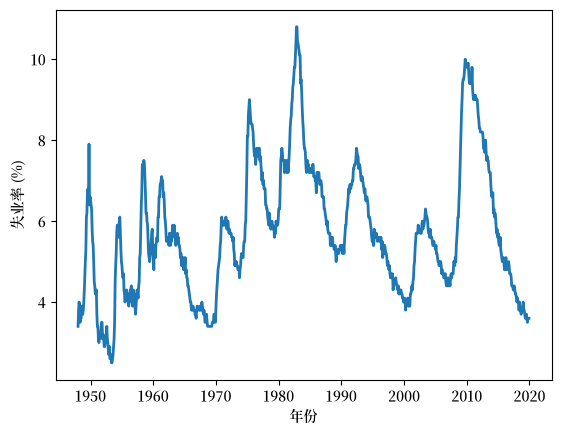

In [6]:
fig, ax = plt.subplots()
ax.plot(pre_covid.index, u_monthly, lw=2)
ax.set_xlabel('年份')
ax.set_ylabel('失业率 (%)')
plt.show()

如 {numref}`fig-unrate-monthly` 所示，失业率在衰退中急剧上升，在复苏中缓慢下降，但它始终保持在一个区间内——在整个战后时期大致为 3% 到 11%。

（请记住这个区间，因为它与单位根之争相关联，我们将在下文讨论。）


## 失业的线性模型

现在让我们使用月度数据来设置并估计模型。

### 模型

我们设失业率被拉回到一个正常水平 $\bar u$：

$$
u_{t+1} = \bar u + \phi\,(u_t - \bar u) + \varepsilon_{t+1},
\qquad \varepsilon_{t+1} \sim N(0, \sigma^2),
$$ (eq:linear)

其中 $0 \le \phi < 1$。

这是一个线性 AR(1)过程模型，写成这种形式使得 $\bar u$ 是序列所回归的水平，而 $\phi$ 度量持续性。

$\phi$ 越接近 1，序列在冲击后返回 $\bar u$ 的速度就越慢；随机游走是极限情形 $\phi = 1$。

### 先验

我们把 $\bar u$、$\phi$ 和 $\sigma$ 视为未知，并对它们施加弱信息先验。

我们给 $\phi$ 一个 $[0, 1)$ 上的均匀先验。

上端点被有意排除，因为这样做可以将我们限制在*平稳*区域内。

这是必要的，我们将在下文看到原因。

同时，这个先验仍然允许 $\phi$ 在数据要求下尽可能地接近 1。

我们将 $\bar u$ 以一个合理的自然率为中心，并配以相当宽的正态先验，并给冲击尺度 $\sigma$ 一个半正态先验。

我们把模型写成一个 NumPyro 函数：每个 `numpyro.sample` 引入一个随机变量，关键字 `obs=` 将最后一个变量与数据绑定，从而提供似然。

In [7]:
def linear_model(u):
    ubar = numpyro.sample("ubar",  dist.Normal(5.5, 2.0))      # 自然率先验
    φ    = numpyro.sample("phi",   dist.Uniform(0.0, 1.0))     # 持续性先验
    σ    = numpyro.sample("sigma", dist.HalfNormal(1.0))       # 波动率先验
    μ = ubar + φ * (u[:-1] - ubar)
    numpyro.sample("u_obs", dist.Normal(μ, σ), obs=u[1:])

向量 `μ` 保存了条件均值 $\bar u + \phi(u_t - \bar u)$，而 `obs=u[1:]` 表示每个下一个值都是从 $N(\mu_t, \sigma^2)$ 中抽取的。

这一条语句就编码了整个似然。（关于编写 NumPyro 模型的更多内容，参见 {doc}`bayes_nonconj`。）

### 估计

我们用 NUTS 对后验进行采样，运行四条链以便检查收敛性。

我们使用 `chain_method="vectorized"`，它在单个设备上同时对所有链进行评估，因此相同的代码在 CPU 或 GPU 上都能不变地运行。

In [8]:
def run_nuts(model, data, seed=0, num_warmup=1000, num_samples=2000, num_chains=4):
    "使用 NUTS 采样器对 NumPyro 模型进行采样。"
    mcmc = MCMC(NUTS(model),
                num_warmup=num_warmup, num_samples=num_samples,
                num_chains=num_chains, chain_method="vectorized",
                progress_bar=False)
    mcmc.run(random.PRNGKey(seed), jnp.asarray(data))
    return mcmc

我们将模型拟合到月度数据。

In [9]:
mcmc_monthly = run_nuts(linear_model, u_monthly)

现在我们检查输出。

In [10]:
mcmc_monthly.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
       phi      0.99      0.00      0.99      0.99      1.00   2904.53      1.00
     sigma      0.21      0.00      0.21      0.20      0.22   4583.96      1.00
      ubar      5.69      1.14      5.71      3.72      7.42   3645.82      1.00

Number of divergences: 0


每一行总结了一个参数的后验。

`mean`、`median` 以及 `5.0%`/`95.0%` 列给出后验均值、中位数和 90% 可信区间；`std` 是后验标准差。

最后两列是收敛诊断：`n_eff` 是有效独立抽样数，`r_hat` 比较链内和链间的变化——一个非常接近 $1.0$ 的值意味着各链一致，采样器已经收敛。

这里 `r_hat` 基本上为 1，`n_eff` 也很大，所以我们可以信任这些抽样。

对我们而言重要的数值是 $\phi$ 的后验：它的质量紧紧地贴向 1。

具体来说，均值和中位数都非常接近 1，而标准差非常小。

换句话说，在月度频率上，美国失业率*几乎*是一个随机游走。

这就是滞后效应的边界。

因此，我们发现自然率观点和滞后效应观点在月度数据中几乎无法区分——估计结果与两者都一致。

这就是为什么那个时代的单位根检验难以平息这场辩论 {cite}`roed1997hysteresis`。


## 随机游走会漂离

虽然上面的估计似乎为单位根假说提供了合理的支持，但有一个充分的理由认为它是错误的。

要看到这个论证，假设失业率真的是一个纯粹的随机游走，其中 $\phi = 1$：

$$
u_{t+1} = u_t + \varepsilon_{t+1}, \qquad \varepsilon_{t+1} \sim N(0, \sigma^2).
$$

那么 $u_t = u_0 + \sum_{s=1}^t \varepsilon_s$，因此其方差无界增长：$\operatorname{Var}(u_t) = t\sigma^2$。

分布会永远扩散，最终概率质量会离开*每一个*有界区间。

我们可以通过模拟许多随机游走路径来观察这一点，用观测到的单月变化来设定冲击大小，并观察它们的扩散。

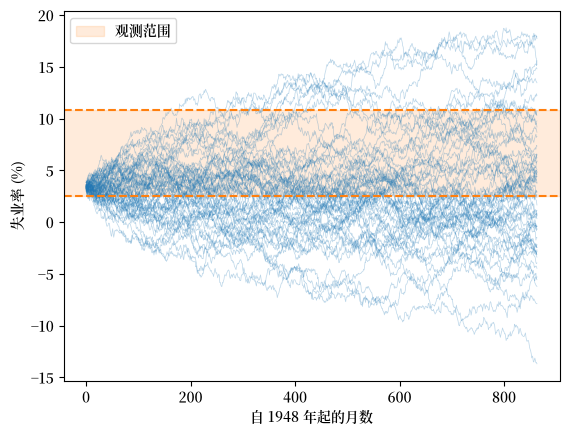

In [11]:
rng = np.random.default_rng(0)
T = len(u_monthly)
σ_rw = np.diff(u_monthly).std()
paths = u_monthly[0] + np.cumsum(rng.normal(0, σ_rw, size=(400, T)), axis=1)

u_min, u_max = u_monthly.min(), u_monthly.max()

fig, ax = plt.subplots()
ax.plot(paths[:60].T, color='C0', lw=0.5, alpha=0.3)
ax.axhspan(u_min, u_max, color='C1', alpha=0.15, label='观测范围')
ax.axhline(u_min, color='C1', ls='--', lw=1.5)
ax.axhline(u_max, color='C1', ls='--', lw=1.5)
ax.set_xlabel('自 1948 年起的月数')
ax.set_ylabel('失业率 (%)')
ax.legend()
plt.show()

在 {numref}`fig-rw-escape` 中，虚线标记了数据中曾出现过的最低和最高失业率，阴影区域是它们之间的区间。

模拟路径像 $\sqrt{t}$ 一样扩散，并迅速蔓延到这个区间之外，甚至包括负的失业率。

随机游走没有锚点，但失业率显然有——它在七十年里一直保持在一个狭窄的区间内。

所以我们已经可以排除精确的随机游走。

当我们检查年度数据时，这一点会更加清楚。



## 月度与年度

月度数据把 $\phi$ 钉在了 1 上。

不同的频率能否让我们看到更多东西？

我们用年末值构造一个年度序列，并对它拟合相同的模型。

In [12]:
u_annual = pre_covid.resample("YE").last().to_numpy()
print(f"{len(u_annual)} annual observations")

72 annual observations


我们对这个更短的序列拟合相同的模型。

In [13]:
mcmc_annual = run_nuts(linear_model, u_annual)

现在我们比较两个频率下 $\phi$ 的后验。

findfont: Failed to find font weight normal, now using 600.


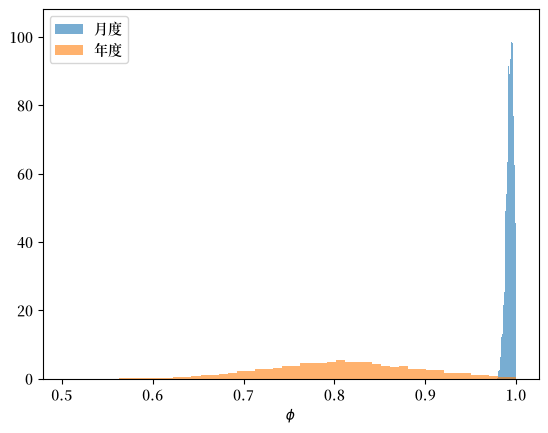

In [14]:
φ_m = np.asarray(mcmc_monthly.get_samples()["phi"])
φ_a = np.asarray(mcmc_annual.get_samples()["phi"])

fig, ax = plt.subplots()
ax.hist(φ_m, bins=50, density=True, alpha=0.6, label='月度')
ax.hist(φ_a, bins=50, density=True, alpha=0.6, label='年度')
ax.set_xlabel('$\\phi$')
ax.legend()
plt.show()

{numref}`fig-phi-post` 说明了我们的主要发现：年度的 $\phi$ 后验明显低于 1，具有清晰的回归，而月度的后验则紧贴边界。

这并不矛盾。

如果月度持续性是 $\phi$，那么对于年末值而言，持续性大约是 $\phi^{12}$，而将一个接近 1 的数字提升到十二次方会把它明显拉到 1 以下——这与我们的年度估计一致。



## 模型遗漏了什么

再次审视 {numref}`fig-unrate-monthly`，我们注意到失业率在衰退中迅速跳升，在复苏中缓慢下降。

这是一种我们当前模型无法复制的*非对称性*。

要弄清楚原因，我们仔细审视模型中唯一随机的部分——冲击。

我们分三步进行：陈述模型对冲击的假设，从数据中恢复冲击，并比较两者。

### 模型对冲击的假设


给定上一期的失业率 $u_t$ 和参数，下一期的失业率是一个确定性的条件均值加上一个冲击：

$$
u_{t+1} = \underbrace{\bar u + \phi\,(u_t - \bar u)}_{\text{条件均值}} + \varepsilon_{t+1},
\qquad \varepsilon_{t+1} \sim N(0, \sigma^2).
$$

重新整理，冲击就是实际发生的值与模型预期值之间的差距：

$$
\varepsilon_{t+1} = u_{t+1} - \big(\bar u + \phi\,(u_t - \bar u)\big).
$$

模型对这些冲击提出了一个强烈且可检验的断言：它们是从一个*对称的*正态分布中独立抽取的。

如果这个断言成立，我们从数据中恢复的冲击应该看起来像一条钟形曲线。

如果它失败，它失败的方式将告诉我们模型遗漏了什么。

### 恢复冲击

我们无法直接读出冲击，因为我们不知道参数 $\bar u$ 和 $\phi$。

所以我们对它们进行估计，为每个参数代入一个单一的代表性值。

我们使用后验中位数——对于快速诊断而言这是一个合理的选择。

In [15]:
med = {k: np.median(np.asarray(mcmc_monthly.get_samples()[k]))
       for k in ("ubar", "phi", "sigma")}
resid = u_monthly[1:] - (med["ubar"] + med["phi"] * (u_monthly[:-1] - med["ubar"]))

`resid` 数组保存了我们估计的冲击，每一个对应一个月度到月度的转移——即模型的**残差**。

切片就是把每个月与它前面的那个月对齐。

`resid` 的每个元素是 $u_{t+1} - \big(\hat{\bar u} + \hat\phi\,(u_t - \hat{\bar u})\big)$，即模型的向前一步预测误差，其中带帽子的符号表示中位数估计。

（因为我们的估计 $\hat\phi$ 非常接近 1，所以这几乎就是月度变化 $u_{t+1} - u_t$。）


### 与高斯分布比较

现在我们来问，这些残差看起来是否是高斯的。

我们叠加一个正态密度，其标准差被设置为等于残差本身的标准差。

这是有意为之的：残差的均值已经接近零，所以匹配方差就使得均值和扩散都一致。

剩下的任何差异就是*形状*上的差异——这正是我们想要分离出来的。

度量形状的一种方式是**偏度（skewness）**，即三阶标准化矩：

$$
\text{skew} = \frac{\frac1n \sum_i (\varepsilon_i - \bar\varepsilon)^3}{\Big(\frac1n \sum_i (\varepsilon_i - \bar\varepsilon)^2\Big)^{3/2}}.
$$

对于任何对称分布，这个度量为零；当右尾更长时，它为正。

现在我们绘制残差并计算它们的偏度：

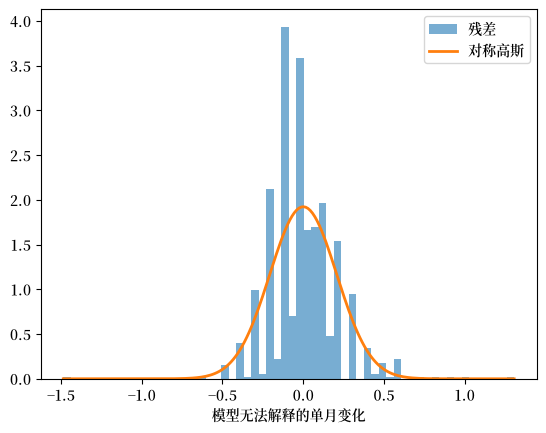

residual skewness = 0.39


In [16]:
def skewness(x):
    x = x - x.mean()
    return (x**3).mean() / x.std()**3

fig, ax = plt.subplots()
ax.hist(resid, bins=60, density=True, alpha=0.6, label='残差')
grid = np.linspace(resid.min(), resid.max(), 200)
gauss = np.exp(-grid**2 / (2 * resid.std()**2)) / (resid.std() * np.sqrt(2 * np.pi))
ax.plot(grid, gauss, 'C1', lw=2, label='对称高斯')
ax.set_xlabel('模型无法解释的单月变化')
ax.legend()
plt.show()

print(f"residual skewness = {skewness(resid):.2f}")

{numref}`fig-resid-skew` 中的残差在两个方面偏离了高斯分布。

它们是*重尾的*且*尖峰的*：比钟形曲线所允许的有更多微小变化，也有更多大幅变化。

此外，它们是*右偏的*，最大的意外出现在上行方向（衰退）。

对称高斯分布（橙色）无法匹配这两个特征：它把向上和向下的冲击视为等可能，也无法容纳偶尔出现的非常大的跳跃。

所以我们的模型注定会误读数据，把罕见的向上跳跃和长期温和的下滑视为*同一种*冲击。


### 关于代入法的说明

一个贝叶斯纯粹主义者会反对说，这里并不存在单一的残差序列。

$(\bar u, \phi)$ 的每一次后验抽样都意味着它自己的残差序列，而我们只是选择了中位数。

这个反对是合理的，而这个检验的完全贝叶斯版本——从后验中模拟整个数据集并比较某个汇总统计量——正是我们在 {doc}`unemployment_shocks` 中所做的。

这个代入法检验是那个更完整测试的一个快速预览。

捕捉这种非对称性是下一讲座的任务，在那里我们对冲击本身而非回归曲线进行建模。

## 练习

讲座 {doc}`ar1_turningpts` 通过模拟未来路径来预测一个 AR(1)过程，既考虑一个**以**固定参数值**为条件**的预测分布，也考虑一个**对**参数后验不确定性**进行积分**的预测分布。

以下练习将这些思想应用到我们拟合的失业模型上。

```{exercise}
:label: unemp_lin_ex1

使用拟合的**年度**模型，从最后观测到的值开始，用两种方式预测未来 $H = 15$ 年的失业率：

1. **代入法**：将参数固定在其后验中位数上，并模拟许多未来路径；
2. **扩展法**：对于每条未来路径，从后验中抽取一组新的 $(\bar u, \phi, \sigma)$。

在同一坐标轴上绘制各自的 90% 预测区间并进行比较。

哪个区间更宽，为什么？
```

```{solution-start} unemp_lin_ex1
:class: dropdown
```

我们使用年度后验抽样，并从最后一个观测值向前模拟。

我们使用年度模型，因为它的持续性 $\phi$ 远比月度频率下更不确定，
所以参数不确定性更有话可说。

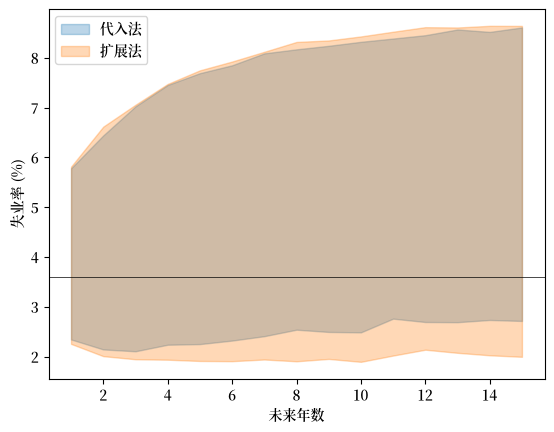

In [17]:
post = mcmc_annual.get_samples()
ubar_s = np.asarray(post["ubar"])
φ_s = np.asarray(post["phi"])
σ_s = np.asarray(post["sigma"])

def sim_future(u_last, ubar, φ, σ, H, rng):
    "从 u_last 开始向前模拟线性模型 H 步。"
    u = np.empty(H)
    prev = u_last
    for h in range(H):
        prev = ubar + φ * (prev - ubar) + rng.normal(0, σ)
        u[h] = prev
    return u

H, N = 15, 2000
u_last = u_annual[-1]
rng = np.random.default_rng(0)

# 代入法：参数固定在后验中位数上
ub0, φ0, σ0 = np.median(ubar_s), np.median(φ_s), np.median(σ_s)
plug = np.array([sim_future(u_last, ub0, φ0, σ0, H, rng) for _ in range(N)])

# 扩展法：为每条路径抽取一组新的后验样本
idx = rng.integers(0, len(φ_s), N)
ext = np.array([sim_future(u_last, ubar_s[i], φ_s[i], σ_s[i], H, rng)
                for i in idx])

fig, ax = plt.subplots()
horizon = np.arange(1, H + 1)
for data, c, lab in [(plug, 'C0', '代入法'), (ext, 'C1', '扩展法')]:
    lo, hi = np.percentile(data, [5, 95], axis=0)
    ax.fill_between(horizon, lo, hi, alpha=0.3, color=c, label=lab)
ax.axhline(u_last, color='k', lw=0.5)
ax.set_xlabel('未来年数')
ax.set_ylabel('失业率 (%)')
ax.legend()
plt.show()

两种预测都从较低的起始值向回归水平 $\bar u$ 上升，且区间随着我们展望得更远而变宽。

扩展法的区间明显更宽，因为它在未来冲击的不确定性之上，还加入了对参数的不确定性——而这里持续性 $\phi$ 和水平 $\bar u$ 都确实是不确定的。

```{solution-end}
```

```{exercise}
:label: unemp_lin_ex2

沿用 Wecker 的方法（参见 {doc}`ar1_turningpts`），我们也可以为一个**路径统计量**——整条未来路径的非线性函数——构造一个预测分布。

将**未来 $H = 8$ 年内的最高失业率**作为统计量：一个衡量未来几年可能有多糟糕的简单指标。

使用扩展模拟（每条路径抽取一组后验样本），为每条路径计算这个最大值，并绘制它的预测分布。

在未来八年内的某个时点失业率达到至少 $7\%$——即衰退区间——的后验预测概率是多少？
```

```{solution-start} unemp_lin_ex2
:class: dropdown
```

我们重用上一练习中的 `sim_future` 和后验抽样。

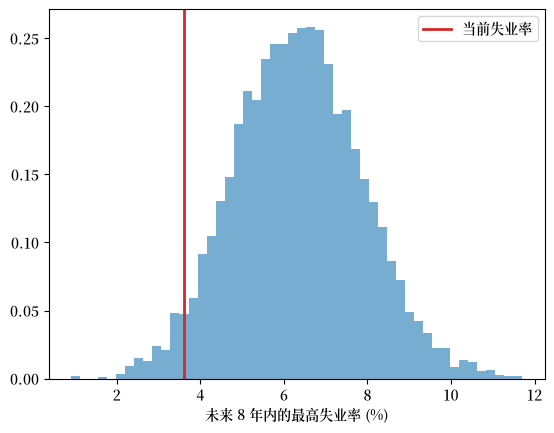

P(unemployment reaches 7% within 8 years) = 0.33


In [18]:
H2, M = 8, 5000
idx = rng.integers(0, len(φ_s), M)
peak = np.array([sim_future(u_last, ubar_s[i], φ_s[i], σ_s[i], H2, rng).max()
                 for i in idx])

fig, ax = plt.subplots()
ax.hist(peak, bins=50, density=True, alpha=0.6)
ax.axvline(u_last, color='C3', lw=2, label='当前失业率')
ax.set_xlabel('未来 8 年内的最高失业率 (%)')
ax.legend()
plt.show()

prob = (peak > 7.0).mean()
print(f"P(unemployment reaches 7% within 8 years) = {prob:.2f}")

预测分布总结了未来几年里可能出现的"最坏情形"，同时对冲击和参数不确定性进行了积分。

从一个周期性低点出发，模型认为在这个视界内失业率相当有可能回到衰退级别。

```{solution-end}
```